In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import warnings

In [16]:
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

In [17]:
warnings.filterwarnings("ignore", category=FutureWarning)

In [18]:
fashion_mnist = fetch_openml(
"fashion-MNIST",
version=1,
as_frame=False,
return_X_y=True
)

In [19]:
X = X.astype('float32')
y = y.astype('int')

print("Dataset shape:", X.shape)

Dataset shape: (10000, 784)


In [20]:
X = X[:10000]
y = y[:10000]

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
X,
y,
test_size=0.2,
stratify=y,
random_state=42
)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")

Training samples: 8000
Testing samples: 2000


In [22]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [24]:
print("\nTraining Linear SVM..")
linear_svm = SVC(kernel='linear')
linear_svm.fit(X_train, y_train)
y_pred_linear = linear_svm.predict(X_test)
linear_accuracy = accuracy_score(y_test, y_pred_linear)
print("Linear SVM Accuracy:", linear_accuracy*100, "%")


Training Linear SVM..
Linear SVM Accuracy: 80.75 %


In [26]:
print("\nTraining RBF SVM...")
rbf_svm = SVC(
    kernel = 'rbf',
    gamma = 'scale'
)

rbf_svm.fit(X_train, y_train)
y_pred_rbf = rbf_svm.predict(X_test)
rbf_accuracy= accuracy_score(y_test, y_pred_rbf)
print("RBF SVM Accuracy:", rbf_accuracy*100, "%")


Training RBF SVM...
RBF SVM Accuracy: 85.25 %


In [28]:
print("\n--- Linear Classification Report ---")
print(classification_report(y_test, y_pred_linear))
print("\n-------------------------------------------------------------------------")

print("\n--- RBF Classification Report ---")
print(classification_report(y_test, y_pred_rbf))


--- Linear Classification Report ---
              precision    recall  f1-score   support

           0       0.68      0.83      0.74       189
           1       0.95      0.97      0.96       205
           2       0.64      0.71      0.67       203
           3       0.83      0.79      0.81       204
           4       0.65      0.62      0.63       195
           5       0.91      0.92      0.91       198
           6       0.63      0.50      0.55       204
           7       0.89      0.89      0.89       204
           8       0.97      0.95      0.96       198
           9       0.92      0.92      0.92       200

    accuracy                           0.81      2000
   macro avg       0.81      0.81      0.81      2000
weighted avg       0.81      0.81      0.81      2000


-----------------------------------------------------

--- RBF Classification Report ---
              precision    recall  f1-score   support

           0       0.79      0.81      0.80       189
    

(0.0, 100.0)

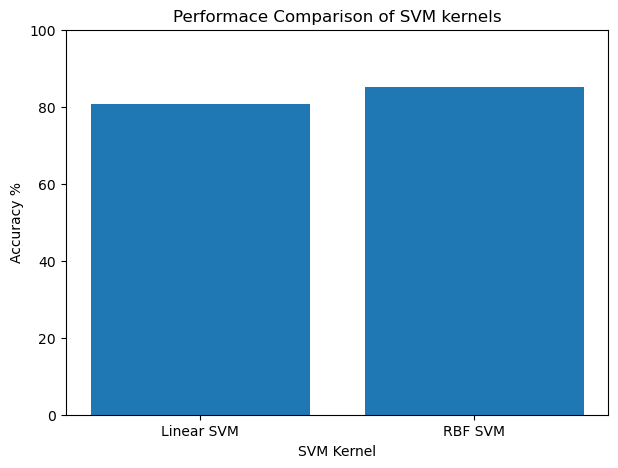

In [30]:
models = ['Linear SVM', 'RBF SVM']
accuracy = [linear_accuracy * 100, rbf_accuracy * 100]
plt.figure(figsize = (7,5))
bars = plt.bar(models, accuracy)
plt.ylabel("Accuracy %")
plt.xlabel("SVM Kernel")
plt.title("Performace Comparison of SVM kernels")
plt.ylim(0,100)

